# Barcelona Noise Prediction: Lidar Building Heights
This notebook downloads the building footprints from OpenStreetMap (OSM) and extracts highly precise height data by evaluating zonal statistics over two high-resolution LiDAR Digital Surface Model TIFFs (`Catalunya-1mtif1777965317095.tif` and `Catalunya-1mtif1777965631099.tif`).
We then aggregate these heights within street-level buffers.

In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt
import os
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterstats import zonal_stats

ox.settings.timeout = 1000

print("Loading street data...")
noise_streets = gpd.read_file("../layers/BCN_noise_streets.gpkg")
print("Streets CRS:", noise_streets.crs)
print("Number of street segments:", len(noise_streets))

Loading street data...
Streets CRS: EPSG:25831
Number of street segments: 15115


## 1. Download Building Data from OSM
We need the footprints to act as our 'cookie cutters' against the LiDAR rasters.

In [2]:
place_name = "Barcelona, Spain"
tags = {'building': True}

print("Downloading building footprints...")
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(noise_streets.crs)
print(f"Loaded {len(buildings)} building footprints.")

Loaded 68662 building footprints.


## 2. Load and Mosaic the LiDAR TIFFs
We will merge the two raster datasets together into a single continuous raster memory object so we can evaluate buildings across the boundary line seamlessly.

In [3]:
tif_paths = [
    "../layers/Digital_terrain_model/superficies-correlacio-Catalunya/Catalunya-1mtif1777965317095.tif",
    "../layers/Digital_terrain_model/superficies-correlacio-Catalunya/Catalunya-1mtif1777965631099.tif"
]

src_files_to_mosaic = []
for fp in tif_paths:
    src = rasterio.open(fp)
    src_files_to_mosaic.append(src)

print("Merging TIFFs (creating mosaic)...")
mosaic, out_trans = merge(src_files_to_mosaic)

# Check CRS 
raster_crs = src_files_to_mosaic[0].crs
print(f"Raster CRS is: {raster_crs}")

if buildings.crs != raster_crs:
    print("Aligning Building footprints explicitly to Raster CRS...")
    buildings = buildings.to_crs(raster_crs)

# Temporarily save the mosaic to disk so rasterstats can compute efficiently in chunks
output_mosaic_path = "../data/processed/merged_lidar.tif"
os.makedirs("../data/processed", exist_ok=True)

out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

print("Saving mosaiced raster temporarily to disk...")
with rasterio.open(output_mosaic_path, "w", **out_meta) as dest:
    dest.write(mosaic)

# Close readers
for src in src_files_to_mosaic:
    src.close()

Merging TIFFs (creating mosaic)...
Raster CRS is: EPSG:25831
Saving mosaiced raster temporarily to disk...


## 3. Extract Zonal Statistics
We drape our building polygons over the mosaiced LiDAR raster and calculate the max/min elevations to extract the 'range' which gives us the actual building height (Difference between roof height and ground level touching the polygon).

Calculating height statistics for each building (zonal_stats). This may take a while...


geometry  \
element  id                                                           
relation 118402   POLYGON ((432186.92 4582237.79, 432192.928 458...   
         155422   POLYGON ((429314.531 4579712.137, 429325.693 4...   
         166399   POLYGON ((430546.795 4580865.293, 430539.951 4...   
         169819   POLYGON ((432065.729 4582085.174, 432017.866 4...   
         1574427  POLYGON ((430277.311 4579483.156, 430293.759 4...   

                  lidar_estimated_height  lidar_max_elev  lidar_mean_elev  
element  id                                                                
relation 118402                      NaN             NaN              NaN  
         155422                      NaN             NaN              NaN  
         166399                      NaN             NaN              NaN  
         169819                      NaN             NaN              NaN  
         1574427                     NaN             NaN              NaN

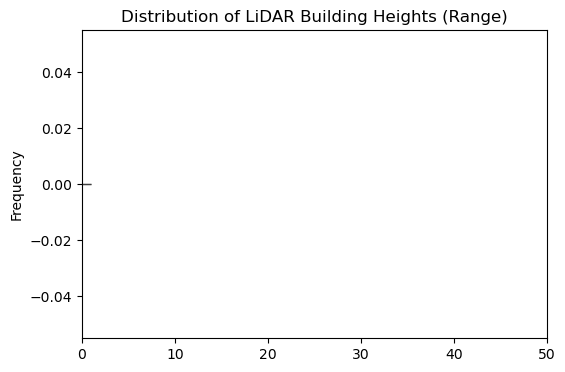

In [ ]:
print("Calculating roof elevations from DSM (Superficies)...")
# all_touched=True ensures we capture data even if the building polygon is smaller than the raster pixel
stats_dsm = zonal_stats(buildings, output_mosaic_path, stats="max", all_touched=True, nodata=-9999.0)

print("Calculating ground elevations from DTM (Elevacions)...")
dtm_path = "../layers/Digital_terrain_model/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1777940893149.tif"
stats_dtm = zonal_stats(buildings, dtm_path, stats="mean", all_touched=True)

# Combine stats
df_dsm = pd.DataFrame(stats_dsm)
df_dtm = pd.DataFrame(stats_dtm)

# True building height = Max Roof Elevation (DSM) - Mean Ground Elevation (DTM)
buildings['lidar_true_height'] = df_dsm['max'] - df_dtm['mean']

# Clean up any weird negative artifacts or NaNs
buildings['lidar_true_height'] = buildings['lidar_true_height'].clip(lower=0).fillna(0)

display(buildings[['geometry', 'lidar_true_height']].head(5))

buildings['lidar_true_height'].plot(kind='hist', bins=50, figsize=(6, 4), color='orange', edgecolor='black')
plt.title('Distribution of True LiDAR Building Heights (DSM max - DTM mean)')
plt.xlim(0, 50)
plt.show()

## 4. Buffer Analysis (Street Matching)
Just like before, we compute the average and maximum building heights enclosed closely by the 50m and 100m street buffers.

In [ ]:
# Before SJOIN, let's make sure streets and buildings share the exact same CRS
if noise_streets.crs != buildings.crs:
    noise_streets = noise_streets.to_crs(buildings.crs)

def calculate_lidar_heights_in_buffer(streets_gdf, buildings_gdf, buffer_size):
    print(f"Evaluating {buffer_size}m buffers...")
    buffered_streets = streets_gdf.copy()
    buffered_streets['geometry'] = buffered_streets.geometry.buffer(buffer_size)
    
    bldgs = buildings_gdf[['lidar_true_height', 'geometry']].copy()
    joined = gpd.sjoin(buffered_streets[['TRAM', 'geometry']], bldgs, how='left', predicate='intersects')
    joined['lidar_true_height'] = joined['lidar_true_height'].fillna(0)
    
    agg_funcs = {
        'lidar_true_height': ['mean', 'max']
    }
    grouped = joined.groupby('TRAM').agg(agg_funcs)
    grouped.columns = [f"lidar_true_h_{col[1]}_{buffer_size}m" for col in grouped.columns]
    
    return grouped.reset_index()

features_50m = calculate_lidar_heights_in_buffer(noise_streets, buildings, 50)
features_100m = calculate_lidar_heights_in_buffer(noise_streets, buildings, 100)

display(features_50m.head())

## 5. Merge, Export and Visualize

In [ ]:
dataset = pd.DataFrame({'street_id': noise_streets['TRAM']})

dataset = dataset.merge(features_50m, left_on='street_id', right_on='TRAM', how='left').drop(columns=['TRAM'])
dataset = dataset.merge(features_100m, left_on='street_id', right_on='TRAM', how='left').drop(columns=['TRAM'])
dataset = dataset.fillna(0)

output_dir = "../data/processed"
dataset.to_csv(os.path.join(output_dir, "lidar_building_heights.csv"), index=False)
print("Exported lidar_building_heights.csv")

# Visualization
viz_gdf = noise_streets.merge(dataset[['street_id', 'lidar_true_h_mean_50m']], left_on='TRAM', right_on='street_id')
vmax_height = viz_gdf['lidar_true_h_mean_50m'].quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 10))
viz_gdf.plot(
    column='lidar_true_h_mean_50m',
    ax=ax,
    cmap='magma',
    linewidth=1.5,
    legend=True,
    legend_kwds={'label': "Average True LiDAR Building Height in 50m Buffer (m)"},
    vmax=vmax_height
)
ax.set_title("Barcelona Street Network: Average Local LiDAR Building Height", fontsize=16)
ax.set_axis_off()
plt.show()